# Constructing a Binomial Stochastic Volatility Tree using GARCH

In [2]:
# Import the necessary libraries
import pandas as pd
import numpy as np
from arch import arch_model
import matplotlib.pyplot as plt
import networkx as nx

# Load the MSFT data 
df = pd.read_csv('MSFT.csv')

# Calculate returns based on the adjusted close prices (S_t - S_t-1) / S_t-1
df['return'] = (df['Adj Close'] - df['Adj Close'].shift(1)) / df['Adj Close'].shift(1) * 100  # Rescale by multiplying by 100

# Drop NaN values (first return will be NaN)
df.dropna(inplace=True)

# Set up the GARCH(1,1) model
garch_model = arch_model(df['return'], vol='Garch', p=1, q=1)

# Fit the model
garch_fit = garch_model.fit(disp="off", options={"ftol": 1e-4, "maxiter": 10000})

# Display the model summary
print(garch_fit.summary())

# Extract the conditional volatility (which is the square root of the conditional variance)
df['Volatility'] = garch_fit.conditional_volatility / 100  # Scale the volatility back down

# Display the first few rows of the DataFrame with calculated volatility
print(df[['return', 'Volatility']].tail())

# After fitting the GARCH model, extract parameters
garch_params = garch_fit.params
df

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2424.84
Distribution:                  Normal   AIC:                           4857.68
Method:            Maximum Likelihood   BIC:                           4878.23
                                        No. Observations:                 1258
Date:                Tue, Feb 25 2025   Df Residuals:                     1257
Time:                        10:11:35   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1431  4.248e-02      3.369  7.539e-04 [5.986e-0

,Date,Adj Close,return,Volatility
1,8/9/19,131.333420,-0.849620,0.014825
2,8/12/19,129.502319,-1.394238,0.014515
3,8/13/19,132.182236,2.069397,0.014695
4,8/14/19,128.201660,-3.011430,0.015286
5,8/15/19,127.914551,-0.223951,0.017601
...,...,...,...,...
1254,8/2/24,408.489990,-2.066600,0.015427
1255,8/5/24,395.149994,-3.265685,0.016267
1256,8/6/24,399.609985,1.128683,0.018801
1257,8/7/24,398.429993,-0.295286,0.018150


# Parameter Initialization and Setup

In [4]:
#T = 1  # Total time in years
nrun = 10 # Number of time steps
dt = 1/252  # Time increment
r = 0.05  # Risk-free rate 
mu = 0  # Adjusted drift term
omega = garch_params['omega']
alpha = garch_params['alpha[1]']
beta = garch_params['beta[1]']
K = 450

# Initial stock price and variance
S_00 = df['Adj Close'].iloc[-1]
init_var = df['Volatility'].iloc[-1]**2

# Print initial parameters
print(f"Initial S_00: {S_00}, sigma_00^2: {init_var}, mu: {mu}")
beta

Initial S_00: 401.799988, sigma_00^2: 0.00030050160102328805, mu: 0


0.8891664363828319

# Stock and Variance Tree Construction

In [6]:
def reconstruct_path(stock_tree, j, i):
    """
    Reconstructs the path of stock prices from level=1 up to (j-1),
    EXCLUDING the root node (0,0).
    Returns a list of stock prices in ascending order from j=1 to j-1.
    """
    path_indices = []
    curr_j = j - 1
    curr_i = i // 2

    while curr_j >= 1:  
        path_indices.append((curr_j, curr_i))
        curr_i //= 2
        curr_j -= 1

    path_indices.reverse()

    path_stocks = []
    for (level, idx) in path_indices:
        path_stocks.append(stock_tree[level][idx])

    return path_stocks


def build_stock_variance_trees_dynamic(df, S_00, init_var, mu, nrun, dt):
    stock_tree = [[S_00]]
    variance_tree = [[init_var]]

    for j in range(1, nrun + 1):
        stock_level = []
        variance_level = []

        for i in range(2**j):
            parent_node = i // 2
            parent_stock = stock_tree[j - 1][parent_node]
            parent_variance = variance_tree[j - 1][parent_node]

            # 1) Compute the child node S_{i,j}
            stock_price = parent_stock * np.exp(
                mu * dt + ((-1) ** i) * np.sqrt(parent_variance * 252 * dt)
            )

            # 2) Reconstruct path from level=1 to (j-1), skipping root (0,0)
            ancestors = reconstruct_path(stock_tree, j, i)
            appended_count = 0

            # 3) Append each ancestor in order
            for ancestor_price in ancestors:
                df = pd.concat(
                    [df, pd.DataFrame({"Adj Close": [ancestor_price]})],
                    ignore_index=True
                )
                appended_count += 1

            # 4) Append the new child node
            df = pd.concat(
                [df, pd.DataFrame({"Adj Close": [stock_price]})],
                ignore_index=True
            )
            appended_count += 1
            
            # 5) Recompute returns
            df["return"] = (
                df["Adj Close"].diff() / df["Adj Close"].shift(1)
            ) * 100
            df = df[np.isfinite(df["return"])]

            # 6) Fit GARCH(1,1)
            garch_model = arch_model(df["return"], vol="Garch", p=1, q=1)
            garch_fit = garch_model.fit(disp="off", options={"ftol": 1e-4, "maxiter": 10000})

            # Extract parameters
            omega = garch_fit.params["omega"]
            alpha = garch_fit.params["alpha[1]"]
            beta  = garch_fit.params["beta[1]"]


            # 7) Compute variance
            variance = omega + beta * parent_variance + alpha * (
                (stock_price - parent_stock) / parent_stock
            ) ** 2

            # Scale variance if necessary
            variance /= 100

            # 8) Remove appended rows
            df = df.iloc[:-appended_count]

            # 9) Store results
            stock_level.append(stock_price)
            variance_level.append(variance)

        stock_tree.append(stock_level)
        variance_tree.append(variance_level)

    return stock_tree, variance_tree


In [7]:
# Build and display the stock and variance trees
stock_tree, variance_tree = build_stock_variance_trees_dynamic(df, S_00, init_var, mu, nrun, dt)

print("\nStock Tree (First 3 Levels):")
for level in stock_tree[:3]:
    print(level)

print("\nVariance Tree (First 3 Levels):")
for level in variance_tree[:3]:
    print(level)



Stock Tree (First 3 Levels):
[401.799988]
[408.82590468950315, 394.8948158737977]
[418.77292940265687, 399.11514954798866, 404.49899528133886, 385.5186722912357]

Variance Tree (First 3 Levels):
[0.00030050160102328805]
[0.0005778943824738634, 0.000577431870970554]
[0.0005738232226181518, 0.0005659454618774074, 0.0005646839981138381, 0.000565916301880761]


# Probability, Up, and Down Factors Tree Construction

In [9]:
def build_probability_tree(stock_tree, variance_tree, r, dt, nrun):
    p_tree = []
    up_tree = []
    down_tree = []

    for j in range(len(stock_tree)):
        p_level = []
        up_level = []
        down_level = []
        for i in range(len(stock_tree[j])):
            variance = variance_tree[j][i]
            u_ij = np.exp(mu * dt + np.sqrt(variance * 252 * dt))
            d_ij = np.exp(mu * dt - np.sqrt(variance * 252 * dt))
            p_ij = (np.exp(r * dt) - d_ij) / (u_ij - d_ij)

            up_level.append(u_ij)
            down_level.append(d_ij)
            p_level.append(p_ij)

        up_tree.append(up_level)
        down_tree.append(down_level)
        p_tree.append(p_level)

    return p_tree, up_tree, down_tree

# Build and display the probability tree
p_tree, up_tree, down_tree = build_probability_tree(
    stock_tree, variance_tree, r, dt, nrun
)
print("Probability Tree:")
for level in p_tree[:3]:
    print(level)
print("\nUp Factors:")
for level in up_tree[:3]:
    print(level)
print("\nDown Factors:")
for level in down_tree[:3]:
    print(level)


Probability Tree:
[0.5013895430515419]
[0.4981172600678495, 0.4981213179060754]
[0.49815308005040115, 0.49822305358379726, 0.49823434078931395, 0.49822331423952726]

Up Factors:
[1.0174861047768453]
[1.024330710454144, 1.0243208546212228]
[1.0242438238933465, 1.0240748383520788, 1.024047672355862, 1.0240742107168102]

Down Factors:
[0.9828144043493544]
[0.9762472117590257, 0.9762566050359129]
[0.9763300267692208, 0.9764911338014909, 0.9765170382150868, 0.9764917322740125]


# Backward Induction for Option Pricing, $V_{i,j}^*$


In [11]:
def compute_option_price(stock_tree, p_tree, K, nrun, r, dt):
    option_values = [[0] * len(level) for level in stock_tree]

    # Compute terminal option values
    final_stock_prices = stock_tree[-1]
    for i in range(len(final_stock_prices)):
        option_values[-1][i] = max(K - final_stock_prices[i], 0)

    # Backward induction
    for j in range(nrun - 1, -1, -1):
        for i in range(0,2**j):
            p_ij = p_tree[j][i]
            discounted_value = np.exp(-r * dt) * (
                p_ij * option_values[j + 1][2 * i] +
                (1 - p_ij) * option_values[j + 1][2 * i + 1]
            )
            intrinsic_value = max(K - stock_tree[j][i], 0)
            option_values[j][i] = max(intrinsic_value, discounted_value)

    return option_values

# Compute and display option prices
option_values = compute_option_price(stock_tree, p_tree, K, nrun, r, dt)
print("Option Values:")
for level in option_values[:3]:
    print(level)


Option Values:
[48.7045946256492]
[41.719208666829495, 55.74829776862997]
[32.50061291287475, 50.885134757989825, 45.68222680557653, 65.76104981637462]


# Free Boundary Estimation at 𝑡=0

In [13]:
def find_free_boundary(S_00, init_var, mu, omega, alpha, beta, r, K, dt, nrun, epsilon, adjustment_factor, max_iterations=10000):
    """
    Finds the optimal free boundary stock price (S_00) where early exercise of an American put option occurs.

    Parameters:
    S_00 : Initial stock price guess.
    init_var : Initial variance.
    mu : Drift term for stock price.
    omega, alpha, beta : GARCH(1,1) parameters for modeling volatility.
    r : Risk-free interest rate.
    K : Strike price of the option.
    dt : Time step size.
    nrun : Number of time steps.
    epsilon : Convergence threshold for stopping the iteration.
    adjustment_factor : Step size for adjusting S_00 in each iteration.
    max_iterations : Maximum allowed iterations (default is 10,000).

    Returns:
    optimal_S_00 : The stock price at the free boundary.
    intrinsic_value : The intrinsic value of the option at that point.
    discounted_value : The discounted option value at that point.

    """

    iteration = 0
    while iteration < max_iterations:
        iteration += 1

        # Rebuild stock and variance trees for the current iteration
        stock_tree, variance_tree = build_stock_variance_trees_dynamic(df, S_00, init_var, mu, nrun, dt)
        
        # Compute the probability tree used for risk-neutral valuation
        p_tree, _, _ = build_probability_tree(stock_tree, variance_tree, r, dt, nrun)

        # Compute option prices based on the stock tree and risk-neutral probabilities
        option_values = compute_option_price(stock_tree, p_tree, K, nrun, r, dt)

        # Compute intrinsic value of the option at the root node (S_00)
        intrinsic_value = max(K - S_00, 0)

        # Compute the discounted expected option value at the root node
        discounted_value = np.exp(-r * dt) * (
            p_tree[0][0] * option_values[1][0] + 
            (1 - p_tree[0][0]) * option_values[1][1]
        )

        # Compute the absolute error between intrinsic value and discounted value
        error = abs(discounted_value - intrinsic_value)

        # Stop iterating if the error is within the tolerance epsilon
        if error < epsilon:
            return S_00, intrinsic_value, discounted_value

        # Adjust S_00 based on whether the discounted value is above or below intrinsic value
        if discounted_value > intrinsic_value:
            S_00 -= adjustment_factor  # Decrease S_00 to search for the free boundary
        else:
            S_00 += adjustment_factor  # Increase S_00 to search for the free boundary

        # Ensure S_00 remains within valid bounds (it cannot be negative or exceed K)
        if S_00 <= 0 or S_00 >= K:
            raise ValueError("S_00 out of bounds.")

    # If max_iterations is reached without convergence, raise an error
    raise RuntimeError("Convergence not achieved.")


# Set tolerance and adjustment step size for finding the free boundary
epsilon = 0.01  # Convergence threshold for stopping the iteration
adjustment_factor = 0.01  # Step size for adjusting S_00 in each iteration

# Run the function to determine the free boundary stock price
optimal_S_00, intrinsic_value, discounted_value = find_free_boundary(
    391.46, init_var, mu, omega, alpha, beta, r, K, dt, nrun,
    epsilon=epsilon, adjustment_factor=adjustment_factor
)

# Print results
print(f"Optimal S_00 found: {optimal_S_00}")
print(f"Intrinsic Value: {intrinsic_value}")
print(f"Discounted Value: {discounted_value}")


Optimal S_00 found: 391.46
Intrinsic Value: 58.54000000000002
Discounted Value: 58.549964726023


In [14]:
#Rebuild the stock and variance trees using the optimal S_00
stock_tree, variance_tree = build_stock_variance_trees_dynamic(df, optimal_S_00, init_var, mu, nrun, dt)

#Recompute the option values using the rebuilt stock tree
p_tree, up_tree, down_tree= build_probability_tree(stock_tree, variance_tree, r, dt, nrun)
option_values = compute_option_price(stock_tree, p_tree, K, nrun, r, dt)

# Identifying the Free Boundary

In [16]:
def identify_free_boundary(stock_tree, option_values, K, nrun):
    results = []

    # Start from j=1 to avoid checking at time step 0
    for j in range(1, nrun):  
        found_boundary = False  # Track if a free boundary transition is found for the current time step
        for i in range(len(stock_tree[j]) - 1):  # Iterate through nodes at time step j
            # Calculate the intrinsic value at nodes i and i+1
            intrinsic_value_i = max(0, K - stock_tree[j][i])
            intrinsic_value_next = max(0, K - stock_tree[j][i + 1])

            # Check the free boundary condition
            if option_values[j][i] > intrinsic_value_i and option_values[j][i + 1] <= intrinsic_value_next:
                stock_price_i = stock_tree[j][i]
                stock_price_next = stock_tree[j][i + 1]
                results.append((j, i, stock_price_i, stock_price_next))  # Append all four required values
                found_boundary = True
                break  # Stop searching after finding the free boundary in this time step

        if not found_boundary:
            results.append((j, None, None, None))  # Indicate no free boundary transition for this time step

    return results

# Call the function to identify free boundary transitions
free_boundary_results = identify_free_boundary(stock_tree, option_values, K, nrun)

# Display the results
print("\nFree Boundary Results:")
for result in free_boundary_results:
    j, i, stock_price_i, stock_price_next = result
    if i is not None:
        print(f"Time step {j}:")
        print(f"  Stock price at i-th node (continuation region): {stock_price_i:.2f}")
        print(f"  Stock price at (i+1)-th node (exercise region): {stock_price_next:.2f}")
    else:
        print(f"Time step {j}: No free boundary transition found.")



Free Boundary Results:
Time step 1: No free boundary transition found.
Time step 2:
  Stock price at i-th node (continuation region): 407.99
  Stock price at (i+1)-th node (exercise region): 388.85
Time step 3:
  Stock price at i-th node (continuation region): 417.87
  Stock price at (i+1)-th node (exercise region): 398.35
Time step 4:
  Stock price at i-th node (continuation region): 407.92
  Stock price at (i+1)-th node (exercise region): 389.00
Time step 5:
  Stock price at i-th node (continuation region): 417.84
  Stock price at (i+1)-th node (exercise region): 398.54
Time step 6:
  Stock price at i-th node (continuation region): 428.13
  Stock price at (i+1)-th node (exercise region): 407.95
Time step 7:
  Stock price at i-th node (continuation region): 437.87
  Stock price at (i+1)-th node (exercise region): 417.74
Time step 8:
  Stock price at i-th node (continuation region): 448.72
  Stock price at (i+1)-th node (exercise region): 428.67
Time step 9:
  Stock price at i-th node

# Plotting Free Boundary Path

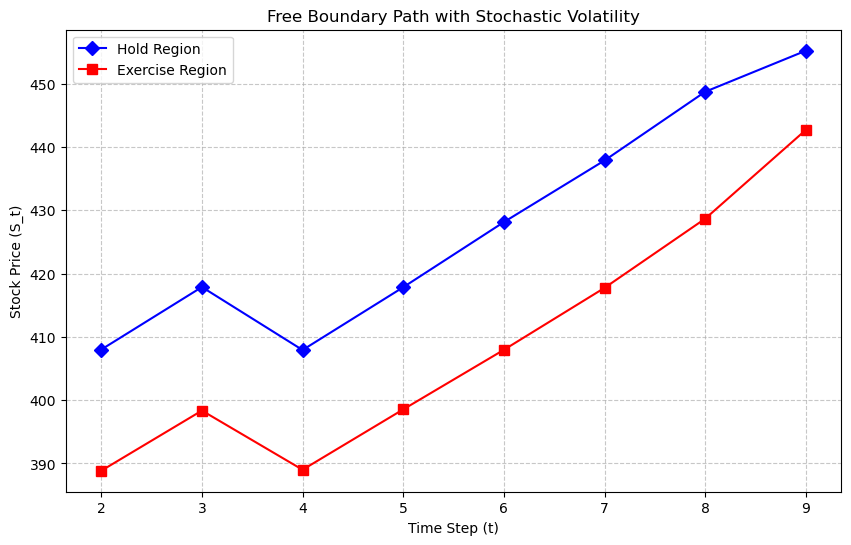

In [18]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Extract data from free_boundary_results
time_steps = []
S_t_i_values = []
S_t_i_plus_1_values = []

for result in free_boundary_results:
    j, i, stock_price_i, stock_price_next = result
    if i is not None:  # Only include valid free boundary transitions
        time_steps.append(int(j))  # Ensure time steps are integers
        S_t_i_values.append(stock_price_i)
        S_t_i_plus_1_values.append(stock_price_next)

# Create the main figure
plt.figure(figsize=(10, 6))

# Plot the main graph with markers
plt.plot(time_steps, S_t_i_values, 'bD-', label="Hold Region", markersize=7)
plt.plot(time_steps, S_t_i_plus_1_values, 'rs-', label="Exercise Region", markersize=7)

# Labels and title
plt.xlabel('Time Step (t)')
plt.ylabel('Stock Price (S_t)')
plt.title('Free Boundary Path with Stochastic Volatility')

# Set x-ticks dynamically based on the range of time steps
step_interval = max(1, len(time_steps) // 10)  # Set x-ticks every ~10% of the range
plt.xticks(range(min(time_steps), max(time_steps)+1, step_interval))

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# # Create an inset plot (zoomed-in view for the last 10 time steps)
#ax_inset = inset_axes(plt.gca(), width="35%", height="35%", loc='upper right')

# # Adjust the zoom range for the last 10 points
# num_steps = len(time_steps)
# start_zoom = max(0, num_steps - 10)

# ax_inset.plot(time_steps[start_zoom:], S_t_i_values[start_zoom:], 'bD-', markersize=6)
# ax_inset.plot(time_steps[start_zoom:], S_t_i_plus_1_values[start_zoom:], 'rs-', markersize=6)

# Set zoomed-in x and y limits based on the last 10 points
# ax_inset.set_xlim(time_steps[start_zoom], time_steps[-1])
# ax_inset.set_ylim(min(S_t_i_values[start_zoom:]), max(S_t_i_values[start_zoom:]) + 5)
# ax_inset.grid(True, linestyle='--', alpha=0.7)

plt.savefig('Free_Boundary_Path_with_Stochastic_Volatility.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()
